In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import *
import random
import numpy as np
import torch
import torch_geometric
from model import Encoder,WeightSumDecoder
from data import get_feature,get_zt_ts
from utils import mins_cross_entropy,shuffle_rows
import pandas as pd
import pickle
import sys
sys.path.insert(1, '../')
from Harmonic_degree import *

In [2]:
torch.__version__,torch_geometric.__version__,np.__version__

('2.5.1', '2.8.0.dev20260103', '1.26.4')

In [3]:
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

In [4]:
# Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
    data_2 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

50


# Weaver

In [5]:
g = data_4["Animal net: Weaver"]
print(len(g.nodes()))

117


In [6]:
# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)

L = len(g.nodes())
result = []
value = L // 2
# Step 1: Build the original list (halvings)
base = []
while value >= 1:
    base.append(value)
    value //= 2
# Step 2: Insert midpoints
lengths = []
for i in range(len(base) - 1):
    lengths.append(base[i])
    midpoint = (base[i] + base[i + 1]) // 2
    lengths.append(midpoint)
lengths.append(base[-1])  # Add the last element
# Step 3: Add L, 7/8*L, 3/4*L, 5/8*L
extra = [L, int(7 * L / 8), int(3 * L / 4), int(5 * L / 8)]
# Step 4: Combine and deduplicate
full_list = list(set(lengths + extra))
full_list.sort(reverse=True)  # descending order if you prefer
lengths = full_list
print(lengths)

CL =[]
LOSS =[]
for l in lengths:
    s = 2050
    torch.manual_seed(s)
    np.random.seed(s)
    random.seed(s)
    #device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    device = 'cpu'
    # Define model and optimizer
    macro_node = l
    encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 2).to(device)
    decoder = WeightSumDecoder(macro_node)
    op = torch.optim.Adam(encoder.parameters(),lr=0.0001)
    # record the loss
    lss_train = []
    lss_ce = []
    for e in tqdm(range(2000)):
        # Partition function evaluation
        group = encoder(X,edge_index)
        new_p = decoder(group,adj.float())
        yhat = get_zt_ts(new_p,ts)
        l0 = torch.mean(torch.abs(y-yhat))
        # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
        sgroup = shuffle_rows(group)
        l1 = mins_cross_entropy(sgroup,group)
        loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
        # backpropagation and gradient decent
        op.zero_grad()
        loss.backward()
        op.step()
        # recording
        lss_train.append(l0.item())
        lss_ce.append(l1.item())
    final_loss = lss_train[-1]
    a = group.cpu().detach().t().numpy()
    # Number of samples
    N = 25
    # To store all the cluster dictionaries
    cluster_samples = []
    # For N repetitions
    for _ in range(N):
        clusters = {}
        for col_idx in range(a.shape[1]):
            # The probability distribution for this column
            probs = a[:, col_idx]
            # Possible row indices
            row_indices = np.arange(a.shape[0])
            # Sample one row index according to the column probabilities
            sampled_row = np.random.choice(row_indices, p=probs)
            clusters[col_idx] = sampled_row
        cluster_samples.append(clusters)
    CL.append(cluster_samples)
    LOSS.append(final_loss)

[117, 102, 87, 73, 58, 43, 29, 21, 14, 10, 7, 5, 3, 2, 1]


100%|██████████| 2000/2000 [00:06<00:00, 301.61it/s]


In [7]:
V = []
for cluster_samples in CL:
    HDS = []
    for clusters in cluster_samples:
        G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(g,clusters)
        Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
        HDS.append(Values)
    HDS=np.array(HDS)
    V.append(HDS)

# Compute statistics
L = len(V)
means = np.zeros((6, L))
q25s = np.zeros((6, L))
q75s = np.zeros((6, L))
for i, mat in enumerate(V):  # mat is (N, 6)
    means[:, i] = np.mean(mat, axis=0)
    q25s[:, i] = np.percentile(mat, 25, axis=0)
    q75s[:, i] = np.percentile(mat, 75, axis=0)

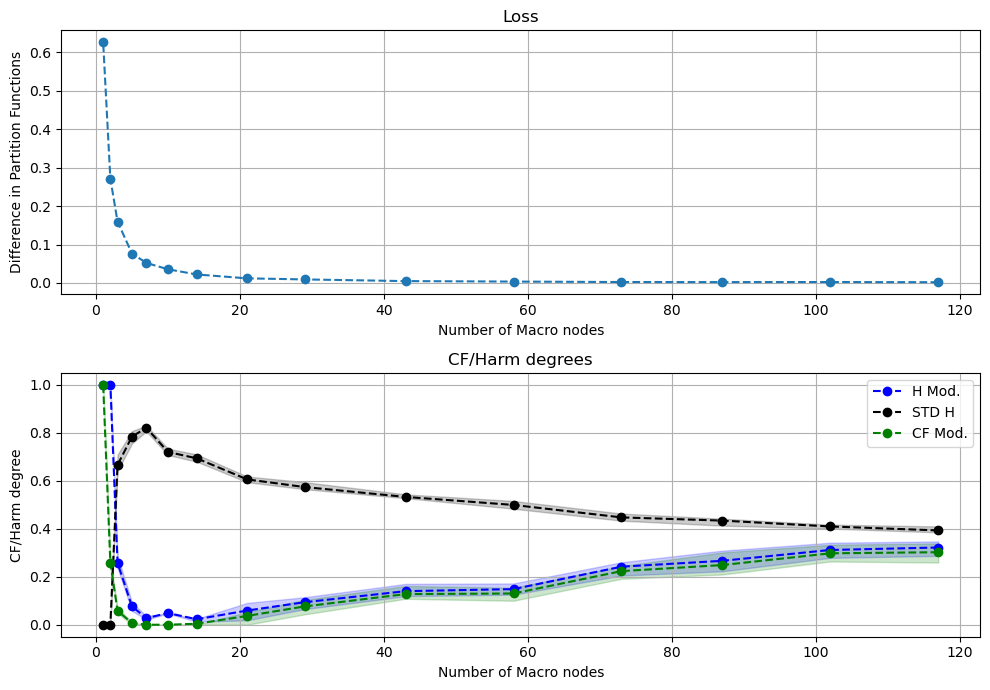

In [8]:
# Set up the subplots
f, ax = plt.subplots(2, 1, figsize=(10, 7))
ax = ax.flatten()

# First plot: Loss
ax[0].plot(lengths, LOSS, marker = 'o', linestyle = '--')
ax[0].set_ylabel("Difference in Partition Functions")
ax[0].set_xlabel("Number of Macro nodes")
ax[0].set_title("Loss")
ax[0].grid(True)

# Second plot: Means and IQRs for selected values
selected_indices = [1, 2, 4]
line_styles = ['--', '--', '--']
colors = ['b', 'k', 'g']
custom_labels = ['H Mod.', 'STD H', 'CF Mod.']

for j, (idx, ls, color, label) in enumerate(zip(selected_indices, line_styles, colors, custom_labels)):
    ax[1].plot(lengths, means[idx], linestyle=ls, color=color, marker='o', label=label)
    ax[1].fill_between(lengths, q25s[idx], q75s[idx], color=color, alpha=0.2, label=None)

ax[1].set_xlabel('Number of Macro nodes')
ax[1].set_ylabel('CF/Harm degree')
ax[1].set_title('CF/Harm degrees')
ax[1].legend()
ax[1].grid(True)
# Adjust layout
plt.tight_layout()
#f.savefig("Weav_DD_plot.pdf")

## Try one sample for several macro nodes

In [9]:
# PUT THE SEED EVERYTIME
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'


# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)


# Define model and optimizer
macro_node = int(len(g.nodes())/2)
encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 1).to(device)
decoder = WeightSumDecoder(macro_node)
op = torch.optim.Adam(encoder.parameters(),lr=0.0001)

# record the loss
lss_train = []
lss_ce = []
for e in tqdm(range(2000)):
    # Partition function evaluation
    group = encoder(X,edge_index)
    new_p = decoder(group,adj.float())
    yhat = get_zt_ts(new_p,ts)
    l0 = torch.mean(torch.abs(y-yhat))
    
    # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
    sgroup = shuffle_rows(group)
    l1 = mins_cross_entropy(sgroup,group)
    
    loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
    
    # backpropagation and gradient decent
    op.zero_grad()
    loss.backward()
    op.step()
    
    # recording
    lss_train.append(l0.item())
    lss_ce.append(l1.item())

a = group.cpu().detach().t().numpy()

# Take one sample


clusters = {}
for col_idx in range(a.shape[1]):
        # The probability distribution for this column
    probs = a[:, col_idx]
        # Possible row indices
    row_indices = np.arange(a.shape[0])
        # Sample one row index according to the column probabilities
    sampled_row = np.random.choice(row_indices, p=probs)
    clusters[col_idx] = sampled_row

# Example output
#print(cluster_samples[1])

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:07<00:00, 265.58it/s]


       H  Mod. H   Var. H       CF  Mod. CF  Var. CF
0.111111  0.1825 0.438369 0.059829    0.175 0.521009


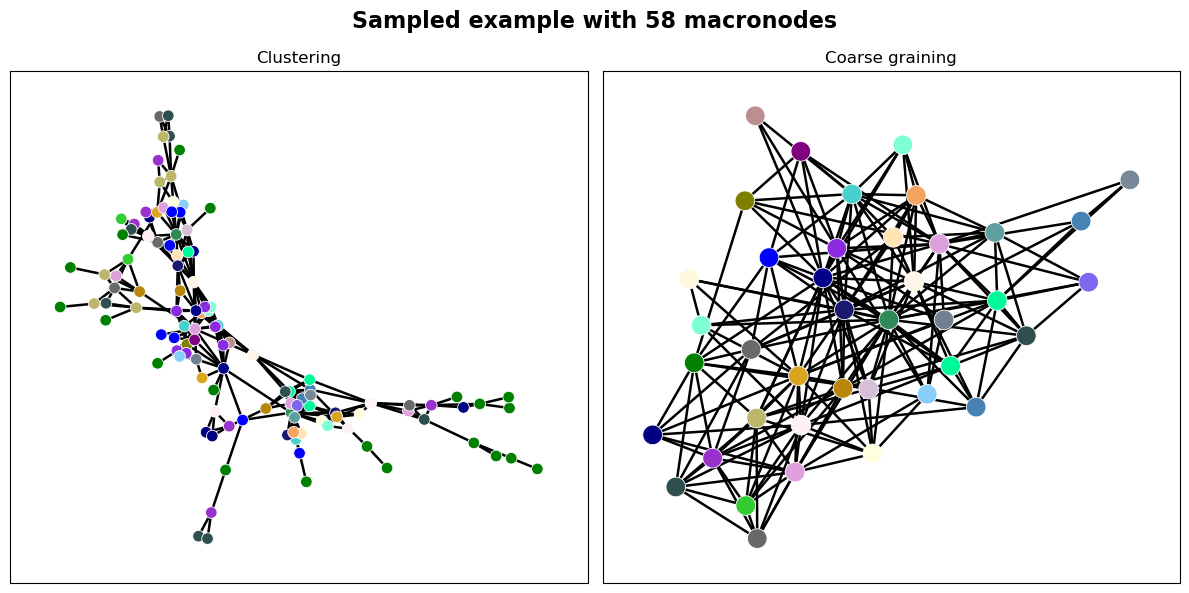

In [10]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(g,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(g,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in g.nodes()]
layout = nx.spring_layout(g, iterations=1000)
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(g,ax=ax[0],pos=layout,node_color=colors,node_size = 70)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(g,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
# Add a big title for the whole figure
f.suptitle(f"Sampled example with {macro_node} macronodes", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"Weav_DD_{macro_node}.pdf")

In [38]:
# PUT THE SEED EVERYTIME
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'


# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)


# Define model and optimizer
macro_node = int(len(g.nodes())/4)
encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 1).to(device)
decoder = WeightSumDecoder(macro_node)
op = torch.optim.Adam(encoder.parameters(),lr=0.0001)

# record the loss
lss_train = []
lss_ce = []
for e in tqdm(range(2000)):
    # Partition function evaluation
    group = encoder(X,edge_index)
    new_p = decoder(group,adj.float())
    yhat = get_zt_ts(new_p,ts)
    l0 = torch.mean(torch.abs(y-yhat))
    
    # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
    sgroup = shuffle_rows(group)
    l1 = mins_cross_entropy(sgroup,group)
    
    loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
    
    # backpropagation and gradient decent
    op.zero_grad()
    loss.backward()
    op.step()
    
    # recording
    lss_train.append(l0.item())
    lss_ce.append(l1.item())

a = group.cpu().detach().t().numpy()

# Take one sample


clusters = {}
for col_idx in range(a.shape[1]):
        # The probability distribution for this column
    probs = a[:, col_idx]
        # Possible row indices
    row_indices = np.arange(a.shape[0])
        # Sample one row index according to the column probabilities
    sampled_row = np.random.choice(row_indices, p=probs)
    clusters[col_idx] = sampled_row

# Example output
#print(cluster_samples[1])

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:08<00:00, 247.62it/s]


       H   Mod. H   Var. H       CF  Mod. CF  Var. CF
0.034188 0.085333 0.551657 0.017094     0.08 0.636042


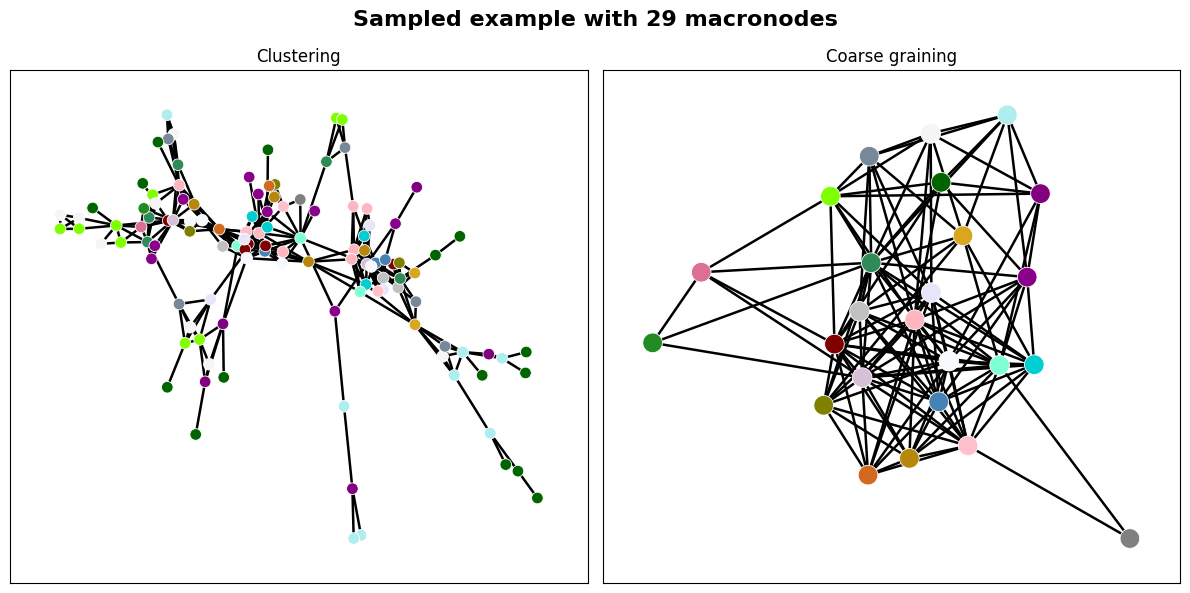

In [50]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(g,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(g,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in g.nodes()]
layout = nx.spring_layout(g, iterations=1000)
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(g,ax=ax[0],pos=layout,node_color=colors,node_size = 70)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(g,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
# Add a big title for the whole figure
f.suptitle(f"Sampled example with {macro_node} macronodes", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Weav_DD_{macro_node}.pdf")

In [74]:
# PUT THE SEED EVERYTIME
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'


# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)


# Define model and optimizer
macro_node = int(len(g.nodes())/8)
encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 1).to(device)
decoder = WeightSumDecoder(macro_node)
op = torch.optim.Adam(encoder.parameters(),lr=0.0001)

# record the loss
lss_train = []
lss_ce = []
for e in tqdm(range(2000)):
    # Partition function evaluation
    group = encoder(X,edge_index)
    new_p = decoder(group,adj.float())
    yhat = get_zt_ts(new_p,ts)
    l0 = torch.mean(torch.abs(y-yhat))
    
    # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
    sgroup = shuffle_rows(group)
    l1 = mins_cross_entropy(sgroup,group)
    
    loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
    
    # backpropagation and gradient decent
    op.zero_grad()
    loss.backward()
    op.step()
    
    # recording
    lss_train.append(l0.item())
    lss_ce.append(l1.item())

a = group.cpu().detach().t().numpy()

# Take one sample


clusters = {}
for col_idx in range(a.shape[1]):
        # The probability distribution for this column
    probs = a[:, col_idx]
        # Possible row indices
    row_indices = np.arange(a.shape[0])
        # Sample one row index according to the column probabilities
    sampled_row = np.random.choice(row_indices, p=probs)
    clusters[col_idx] = sampled_row

# Example output
#print(cluster_samples[1])

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:07<00:00, 273.10it/s]


       H   Mod. H   Var. H  CF  Mod. CF  Var. CF
0.017094 0.009524 0.684669 0.0      0.0 0.797732


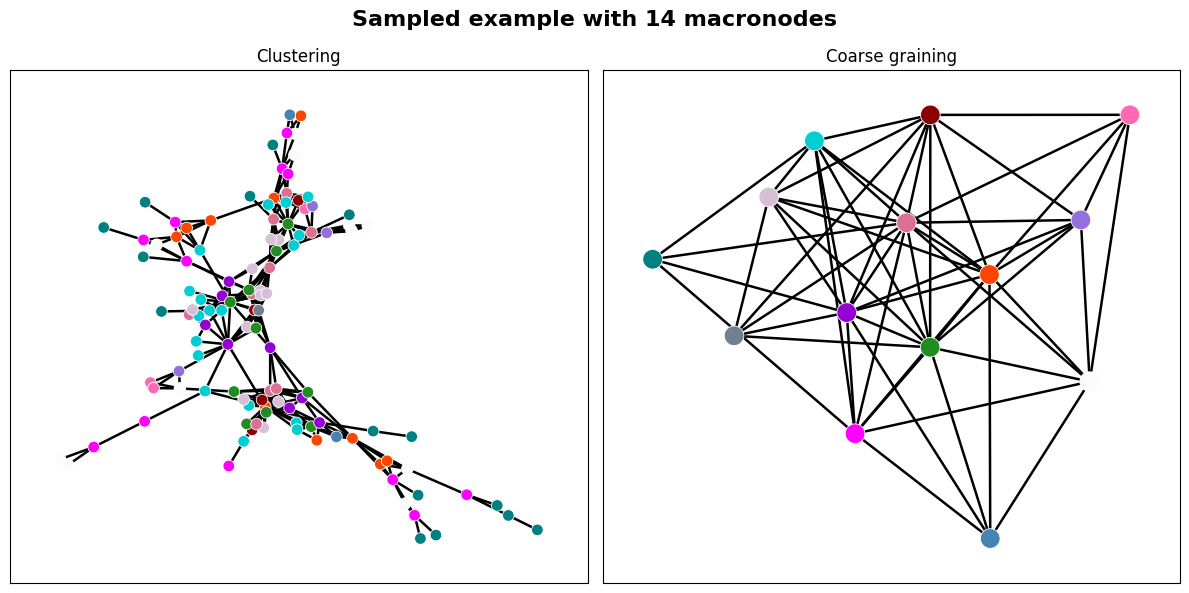

In [76]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(g,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(g,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in g.nodes()]
layout = nx.spring_layout(g, iterations=1000)
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(g,ax=ax[0],pos=layout,node_color=colors,node_size = 70)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(g,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
# Add a big title for the whole figure
f.suptitle(f"Sampled example with {macro_node} macronodes", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Weav_DD_{macro_node}.pdf")

In [67]:
# PUT THE SEED EVERYTIME
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'


# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)


# Define model and optimizer
macro_node = int(len(g.nodes())/16)
encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 1).to(device)
decoder = WeightSumDecoder(macro_node)
op = torch.optim.Adam(encoder.parameters(),lr=0.0001)

# record the loss
lss_train = []
lss_ce = []
for e in tqdm(range(2000)):
    # Partition function evaluation
    group = encoder(X,edge_index)
    new_p = decoder(group,adj.float())
    yhat = get_zt_ts(new_p,ts)
    l0 = torch.mean(torch.abs(y-yhat))
    
    # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
    sgroup = shuffle_rows(group)
    l1 = mins_cross_entropy(sgroup,group)
    
    loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
    
    # backpropagation and gradient decent
    op.zero_grad()
    loss.backward()
    op.step()
    
    # recording
    lss_train.append(l0.item())
    lss_ce.append(l1.item())

a = group.cpu().detach().t().numpy()

# Take one sample


clusters = {}
for col_idx in range(a.shape[1]):
        # The probability distribution for this column
    probs = a[:, col_idx]
        # Possible row indices
    row_indices = np.arange(a.shape[0])
        # Sample one row index according to the column probabilities
    sampled_row = np.random.choice(row_indices, p=probs)
    clusters[col_idx] = sampled_row

# Example output
#print(cluster_samples[1])

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:07<00:00, 279.97it/s]


       H   Mod. H   Var. H  CF  Mod. CF  Var. CF
0.068376 0.040816 0.753837 0.0      0.0 0.936529


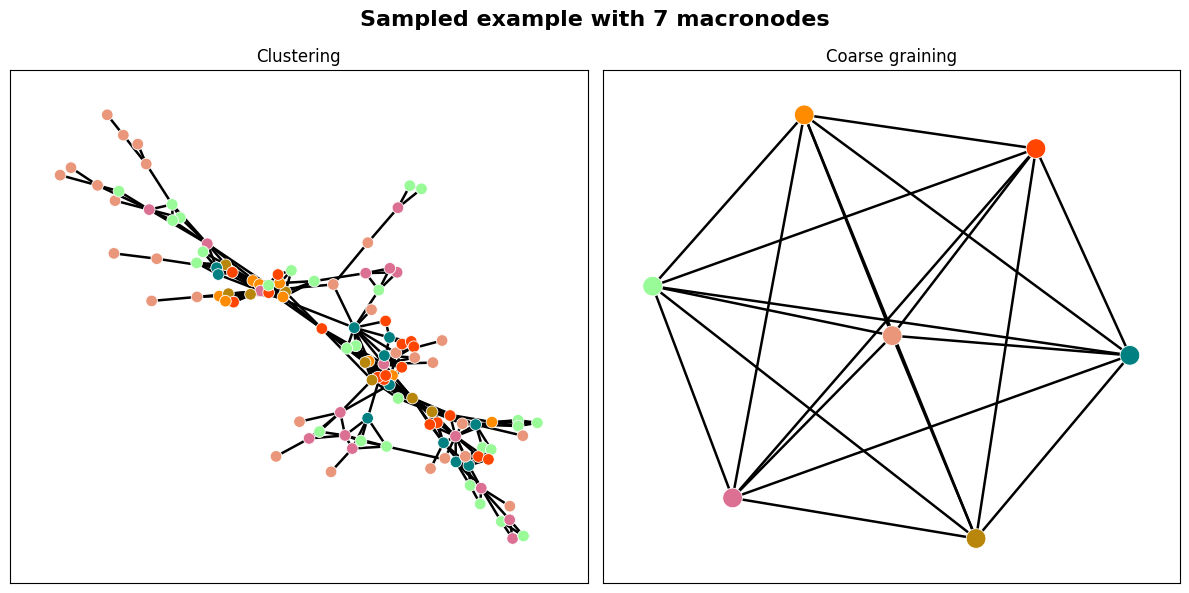

In [73]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(g,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(g,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in g.nodes()]
layout = nx.spring_layout(g, iterations=1000)
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(g,ax=ax[0],pos=layout,node_color=colors,node_size = 70)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(g,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
# Add a big title for the whole figure
f.suptitle(f"Sampled example with {macro_node} macronodes", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Weav_DD_{macro_node}.pdf")

# Facebook

In [5]:
g=data_1["Facebook"]
mapping = {node: idx for idx, node in enumerate(sorted(g.nodes()))}
g = nx.relabel_nodes(g, mapping)
print(len(g.nodes()))

2888


In [78]:
# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)

L = len(g.nodes())
result = []
value = L // 2
# Step 1: Build the original list (halvings)
base = []
while value >= 1:
    base.append(value)
    value //= 2
# Step 2: Insert midpoints
lengths = []
for i in range(len(base) - 1):
    lengths.append(base[i])
    midpoint = (base[i] + base[i + 1]) // 2
    lengths.append(midpoint)
lengths.append(base[-1])  # Add the last element
# Step 3: Add L, 7/8*L, 3/4*L, 5/8*L
extra = [L, int(7 * L / 8), int(3 * L / 4), int(5 * L / 8)]
# Step 4: Combine and deduplicate
full_list = list(set(lengths + extra))
full_list.sort(reverse=True)  # descending order if you prefer
lengths = full_list
print(lengths)

CL =[]
LOSS =[]
for l in lengths:
    s = 2050
    torch.manual_seed(s)
    np.random.seed(s)
    random.seed(s)
    #device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    device = 'cpu'
    # Define model and optimizer
    macro_node = l
    encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 2).to(device)
    decoder = WeightSumDecoder(macro_node)
    op = torch.optim.Adam(encoder.parameters(),lr=0.0001)
    # record the loss
    lss_train = []
    lss_ce = []
    for e in tqdm(range(2000)):
        # Partition function evaluation
        group = encoder(X,edge_index)
        new_p = decoder(group,adj.float())
        yhat = get_zt_ts(new_p,ts)
        l0 = torch.mean(torch.abs(y-yhat))
        # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
        sgroup = shuffle_rows(group)
        l1 = mins_cross_entropy(sgroup,group)
        loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
        # backpropagation and gradient decent
        op.zero_grad()
        loss.backward()
        op.step()
        # recording
        lss_train.append(l0.item())
        lss_ce.append(l1.item())
    final_loss = lss_train[-1]
    a = group.cpu().detach().t().numpy()
    # Number of samples
    N = 10
    # To store all the cluster dictionaries
    cluster_samples = []
    # For N repetitions
    for _ in range(N):
        clusters = {}
        for col_idx in range(a.shape[1]):
            # The probability distribution for this column
            probs = a[:, col_idx]
            # Possible row indices
            row_indices = np.arange(a.shape[0])
            # Sample one row index according to the column probabilities
            sampled_row = np.random.choice(row_indices, p=probs)
            clusters[col_idx] = sampled_row
        cluster_samples.append(clusters)
    CL.append(cluster_samples)
    LOSS.append(final_loss)

[2888, 2527, 2166, 1805, 1444, 1083, 722, 541, 361, 270, 180, 135, 90, 67, 45, 33, 22, 16, 11, 8, 5, 3, 2, 1]


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:40<00:00, 49.29it/s]


In [79]:
V = []
for cluster_samples in CL:
    HDS = []
    for clusters in cluster_samples:
        G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(g,clusters)
        Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
        HDS.append(Values)
    HDS=np.array(HDS)
    V.append(HDS)

# Compute statistics
L = len(V)
means = np.zeros((6, L))
q25s = np.zeros((6, L))
q75s = np.zeros((6, L))
for i, mat in enumerate(V):  # mat is (N, 6)
    means[:, i] = np.mean(mat, axis=0)
    q25s[:, i] = np.percentile(mat, 25, axis=0)
    q75s[:, i] = np.percentile(mat, 75, axis=0)

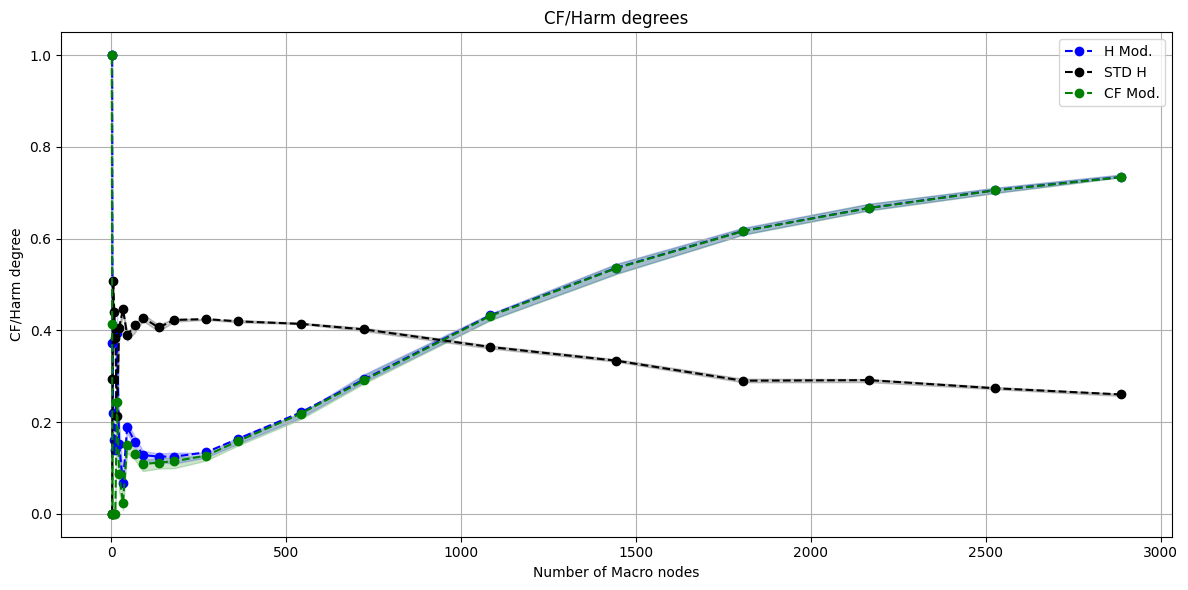

In [84]:
# Set up the subplots
f, ax = plt.subplots(1, 1, figsize=(12, 6))

# Second plot: Means and IQRs for selected values
selected_indices = [1, 2, 4]
line_styles = ['--', '--', '--']
colors = ['b', 'k', 'g']
custom_labels = ['H Mod.', 'STD H', 'CF Mod.']

for j, (idx, ls, color, label) in enumerate(zip(selected_indices, line_styles, colors, custom_labels)):
    ax.plot(lengths, means[idx], linestyle=ls, color=color, marker='o', label=label)
    ax.fill_between(lengths, q25s[idx], q75s[idx], color=color, alpha=0.2, label=None)

ax.set_xlabel('Number of Macro nodes')
ax.set_ylabel('CF/Harm degree')
ax.set_title('CF/Harm degrees')
ax.legend()
ax.grid(True)
# Adjust layout
plt.tight_layout()
plt.show()
